### Training For Baseline Without Optimizer

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Import model, modelIO
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE
from src.model.lstm_bidirectional import BiLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.model.lstm_peephole import PeepholeLSTMModelGPUOptimized
from src.model.lstm_cifg import CIFGLSTMModelGPUOptimized
from src.model.lstm_glu import GLULSTMModelGPUOptimized
from src.model.lstm_layernorm import LayerNormLSTMModelGPUOptimized
from src.model.lstm_residual import ResidualLSTMModelGPUOptimized
# Import attention models
from src.model.lstm_attention_optimized import AttentionLSTMModelGPUOptimized
from src.model.lstm_bidirectional_attention import BiDirectionalAttentionLSTMModelGPUOptimized
from src.model.lstm_cifg_attention import CIFGAttentionLSTMModelGPUOptimized
from src.model.lstm_glu_attention import GLUAttentionLSTMModelGPUOptimized
from src.model.lstm_nested_attention import NestedAttentionLSTMModelGPUOptimized
from src.utils.model_io import save_model, load_and_build_model

# Model registry untuk loop experiments
MODEL_REGISTRY = {
    # 'Optimized': LSTMModelGPUOptimized,
    # 'BiDirectional': BiLSTMModelGPUOptimized,
    # 'Nested': NestedLSTMModelGPUOptimized,
    # 'Peephole': PeepholeLSTMModelGPUOptimized,
    # 'CIFG': CIFGLSTMModelGPUOptimized,
    # 'GLU': GLULSTMModelGPUOptimized,
    # 'LayerNorm': LayerNormLSTMModelGPUOptimized,
    # 'Residual': ResidualLSTMModelGPUOptimized,
    # Attention models
    'Attention': AttentionLSTMModelGPUOptimized,
    # 'BiDirectional-Attention': BiDirectionalAttentionLSTMModelGPUOptimized,
    # 'CIFG-Attention': CIFGAttentionLSTMModelGPUOptimized,
    # 'GLU-Attention': GLUAttentionLSTMModelGPUOptimized,
    # 'Nested-Attention': NestedAttentionLSTMModelGPUOptimized
}

# Export path
CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/lstm_optimized.pkl')
print(CHECKPOINT_PATH)
print(f"📦 Available models: {list(MODEL_REGISTRY.keys())}")

✅ CuPy detected - Using GPU acceleration
✅ CuPy detected - Using GPU acceleration
c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_optimized.pkl
📦 Available models: ['Attention']


In [3]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [4]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

# Extract temporal features
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Create engineered features (TIER 1 & 2)
df['priority_impact_product'] = df['Priority'] * df['Impact']
df['priority_impact_sum'] = df['Priority'] + df['Impact']
df['risk_score'] = (0.6 * df['Priority']) + (0.4 * df['Impact'])
df['priority_squared'] = df['Priority'] ** 2
df['impact_squared'] = df['Impact'] ** 2

# TIER 3: Temporal interactions
df['priority_hour_interaction'] = df['Priority'] * df['hour']
df['impact_hour_interaction'] = df['Impact'] * df['hour']
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("✅ Feature engineering complete")
print(f"   Total columns: {len(df.columns)}")
print(f"   Shape: {df.shape}")

✅ Feature engineering complete
   Total columns: 26
   Shape: (18969, 26)


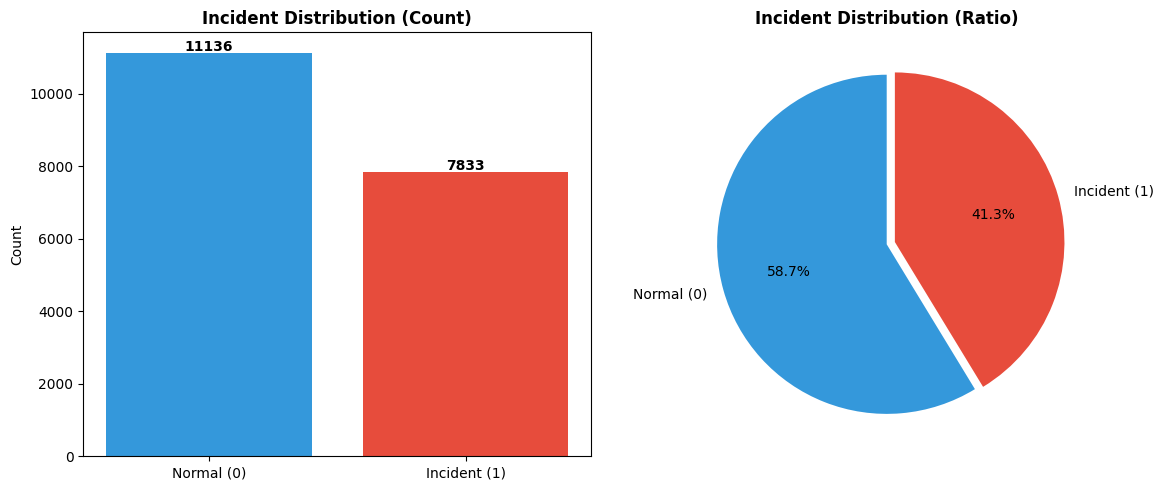


📊 Summary:
   Normal (0): 11,136 (58.7%)
   Incident (1): 7,833 (41.3%)
   Ratio: 1 : 1.4


In [5]:
# === 2.1 Check incident feature ratio ===
# Count values
counts = df['incident'].value_counts()
labels = ['Normal (0)', 'Incident (1)']
# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
axes[0].bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=['#3498db', '#e74c3c'])
axes[0].set_title('Incident Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
# Pie chart
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=labels, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c'], explode=(0, 0.05), startangle=90)
axes[1].set_title('Incident Distribution (Ratio)', fontweight='bold')
plt.tight_layout()
plt.show()
# Print summary
print(f"\n📊 Summary:")
print(f"   Normal (0): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Incident (1): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"   Ratio: 1 : {counts.get(0, 0)/max(counts.get(1, 0), 1):.1f}")

In [6]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)
        

In [7]:
# === 4. Training ===
def train_eval(X, y, label, model_type='Optimized', cw=1, hidden_size=128, patience=10, epochs=500, batch_size=128, lr=0.001, print_every=1, lambda_l2=0.0001):
    """
    Training and evaluation function with support for different LSTM model types.
    
    Args:
        X: Input features (samples, seq_len, features)
        y: Target labels
        label: Label string for identifying this experiment
        model_type: Type of LSTM model to use. Options:
                   'Optimized' (default), 'BiDirectional', 'Nested', 'Peephole'
        cw: Class weight for positive class
        hidden_size: Number of hidden units
        patience: Early stopping patience
        epochs: Maximum training epochs
        batch_size: Batch size for training
        lr: Learning rate
        print_every: Print metrics every N epochs
        lambda_l2: L2 regularization strength
    
    Returns:
        Dictionary containing metrics and predictions
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Export training, val, test sets
    export_dir = '../data/splits'
    os.makedirs(export_dir, exist_ok=True)
    
    np.save(f'{export_dir}/X_train.npy', X_tr)
    np.save(f'{export_dir}/X_val.npy', X_val)
    np.save(f'{export_dir}/X_test.npy', X_te)
    np.save(f'{export_dir}/y_train.npy', y_tr)
    np.save(f'{export_dir}/y_val.npy', y_val)
    np.save(f'{export_dir}/y_test.npy', y_te)
    print(f"💾 Datasets exported to {export_dir}/")
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Get model class from registry
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model_type: {model_type}. Available: {list(MODEL_REGISTRY.keys())}")
    
    ModelClass = MODEL_REGISTRY[model_type]
    print(f"🔧 Initializing {model_type} LSTM model...")
    
    # Initialize Model with class weight
    model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    
    # Thresholding (Default 0.5)
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save the model parameters
    checkpoint_name = f"lstm_{model_type.lower()}_{label.replace('|', '_').replace('=', '')}.pkl"
    checkpoint_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), checkpoint_name)
    save_model(model, checkpoint_path)
    print(f"💾 Model checkpoint saved to: {checkpoint_path}")
    
    # Calculate metrics and return the requested arrays
    return {
        'Model': label,
        'ModelType': model_type,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'ClassWeight': cw,
        'y_test': y_te,    # Ditambahkan sesuai permintaan
        'y_pred': y_pred,  # Ditambahkan sesuai permintaan
        'y_prob': y_prob   # Bonus: probabilitas mentah untuk analisis threshold nanti
    }

In [8]:
# === 4.1 Save Model Data ===
def save_model_assets(result, output_base_path="../data/output"):
    """
    Saves metrics to CSV and plots (Confusion Matrix & PR-Curve) in a dedicated folder.
    Includes both standard (0.5) and optimized threshold metrics.
    """
    # 1. Create a clean folder name (replacing illegal characters)
    model_name = result['Model']
    folder_name = model_name.replace('|', '_').replace('=', '')
    model_dir = os.path.join(output_base_path, folder_name)
    os.makedirs(model_dir, exist_ok=True)

    # 2. Extract ground truth and probabilities
    y_true = result['y_test']
    y_prob = result['y_prob']
    
    # 3. Find the OPTIMUM Threshold (Maximizing F1-Score)
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    # Calculate F1 for each threshold to find the best balance
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    
    # Handle case where thresholds array is shorter than precisions/recalls
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= opt_threshold).astype(int)
    
    pr_auc = average_precision_score(y_true, y_prob)

    # 4. Visualize and Save PR-Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    baseline = sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.scatter(recalls[opt_idx], precisions[opt_idx], color='black', label=f'Best F1 (T={opt_threshold:.3f})')

    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Purity)')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)

    pr_plot_path = os.path.join(model_dir, f"pr_curve_{folder_name}.png")
    plt.savefig(pr_plot_path, bbox_inches='tight')
    plt.close()

    # 5. Prepare full metrics for CSV (including Params & Optimized Metrics)
    save_data = {
        'Model': model_name,
        'ROC_AUC': result['AUC'],
        'PR_AUC': pr_auc,
        'TrainingTime': result['TrainingTime'],
        # Standard Metrics (Threshold 0.5)
        'Std_Threshold': 0.5,
        'Std_Accuracy': result['Accuracy'],
        'Std_Precision': result['Precision'],
        'Std_Recall': result['Recall'],
        'Std_F1': result['F1_Score'],
        # Optimized Metrics (Custom Threshold)
        'Opt_Threshold': opt_threshold,
        'Opt_Accuracy': accuracy_score(y_true, y_pred_opt),
        'Opt_Precision': precision_score(y_true, y_pred_opt),
        'Opt_Recall': recall_score(y_true, y_pred_opt),
        'Opt_F1': f1_score(y_true, y_pred_opt),
        # Training Hyperparameters
        'Epochs': 100, 
        'Batch_Size': 128,
        'LR': 0.001,
        'Optimizer': 'SGD',
        'Rolling_Means': str(result.get('Rolling_Means', 'N/A'))
    }

    # Save CSV
    csv_path = os.path.join(model_dir, f"metrics_{folder_name}.csv")
    pd.DataFrame([save_data]).to_csv(csv_path, index=False)

    # 6. Generate and Save Optimized Confusion Matrix Plot
    plt.figure(figsize=(8, 6))
    cm_opt = confusion_matrix(y_true, y_pred_opt)
    sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Normal', 'Incident'], 
                yticklabels=['Normal', 'Incident'])
    
    plt.title(f"Optimized Confusion Matrix (T={opt_threshold:.3f})\nF1: {f1_score(y_true, y_pred_opt):.4f} | PR-AUC: {pr_auc:.4f}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # 7. Save y_test and y_prob for threshold experimentation
    np.save(os.path.join(model_dir, f"y_test_{folder_name}.npy"), y_true)
    np.save(os.path.join(model_dir, f"y_prob_{folder_name}.npy"), y_prob)
    print(f"      ✅ Saved assets to: {model_dir}")

    plot_path = os.path.join(model_dir, f"cm_opt_{folder_name}.png")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.close() # Free up memory

    print(f"      ✅ Saved assets to: {model_dir}")


🎯 Feature Strategy: full
📊 Base features (15): ['Priority', 'Impact', 'priority_impact_product', 'priority_impact_sum', 'risk_score', 'priority_squared', 'impact_squared', 'priority_hour_interaction', 'impact_hour_interaction', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'hour', 'day_of_week']


Sampling Period: 30min

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480
    Shape: X=(14592, 48, 15) (samples, window, features)

    🧠 Model Type: Attention
      → Running SMOTE with Attention...
      → Training with 15 features (strategy: full)...
💾 Datasets exported to ../data/splits/
🔧 Initializing Attention LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5654 | Val Loss: 0.4519 | Val Acc: 0.7857
Epoch    2/500 | Train Loss: 0.4166 | Val Loss: 0.3965 | Val Acc: 0.7970
Epoch    3/500 

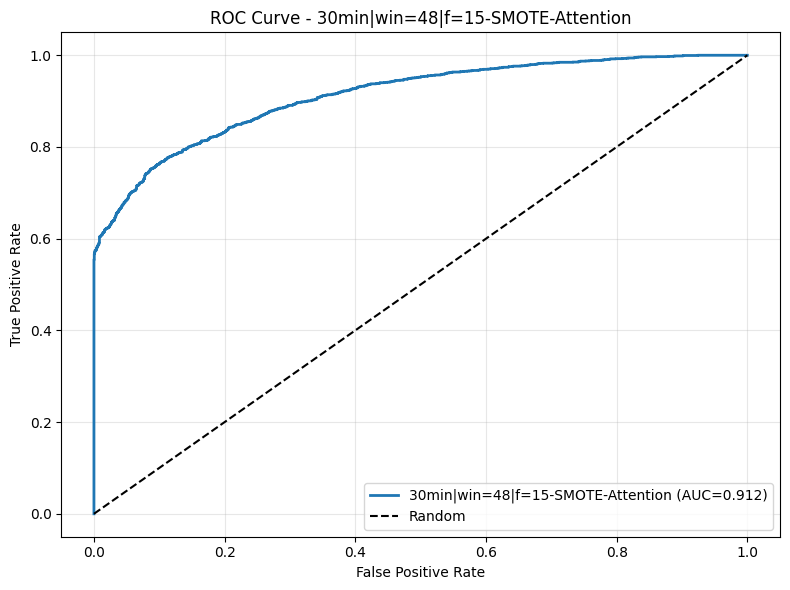

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_attention_30min_win48_f15-SMOTE-Attention.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_attention_30min_win48_f15-SMOTE-Attention.pkl
      ✅ Saved assets to: ../data/output\30min_win48_f15-SMOTE-Attention
      ✅ Saved assets to: ../data/output\30min_win48_f15-SMOTE-Attention

  Window Size: 60
    Data: 14580 samples, Class 0: 10100, Class 1: 4480
    Shape: X=(14580, 60, 15) (samples, window, features)

    🧠 Model Type: Attention
      → Running SMOTE with Attention...
      → Training with 15 features (strategy: full)...
💾 Datasets exported to ../data/splits/
🔧 Initializing Attention LSTM model...
Training: 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 10
---------------------------------------------

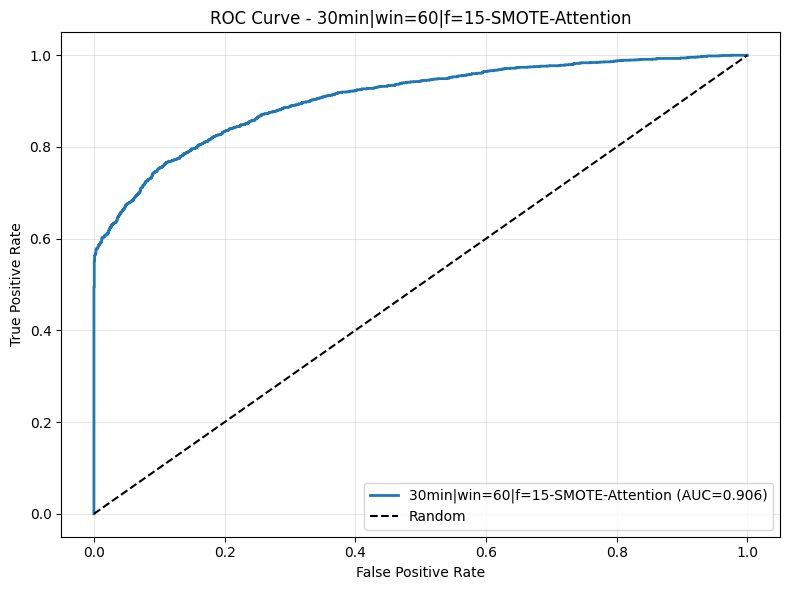

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_attention_30min_win60_f15-SMOTE-Attention.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_attention_30min_win60_f15-SMOTE-Attention.pkl
      ✅ Saved assets to: ../data/output\30min_win60_f15-SMOTE-Attention
      ✅ Saved assets to: ../data/output\30min_win60_f15-SMOTE-Attention

✅ Experiment completed! Total results: 2
   Feature Strategy: full
   Base Features: 15
   Total Features (with rolling): 15
   Models tested: ['Attention']


In [9]:
# === 5. Run Experiment ===

# ============================================================
# CONFIGURATION: Select Feature Strategy
# ============================================================
# Uncomment ONE strategy to test:

# FEATURE_STRATEGY = 'baseline'    # 2 base + rolling = 6 features (current, for validation)
# FEATURE_STRATEGY = 'quick_win'   # 7 base + rolling = 11 features ⭐ RECOMMENDED
# FEATURE_STRATEGY = 'moderate'    # 11 base + rolling = 15 features
FEATURE_STRATEGY = 'full'        # 15 base + rolling = 19 features

FEATURE_STRATEGIES = {
    'baseline': ['Priority', 'Impact'],
    
    'quick_win': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared'
    ],
    
    'moderate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos'
    ],
    
    'full': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'day_sin', 'day_cos',
        'hour', 'day_of_week'
    ]
}

base_feature_cols = FEATURE_STRATEGIES[FEATURE_STRATEGY]
print(f"\n🎯 Feature Strategy: {FEATURE_STRATEGY}")
print(f"📊 Base features ({len(base_feature_cols)}): {base_feature_cols}\n")

# ============================================================
# Experiment Configuration
# ============================================================
sampling_periods = ['30min']
window_sizes = [48, 60]  # Start with best window
model_types = list(MODEL_REGISTRY.keys())
rolling_means = []
results_all = []

# ============================================================
# Main Experiment Loop
# ============================================================
for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    # Build aggregation dictionary for all features
    agg_dict = {'incident': 'sum'}
    for feature in base_feature_cols:
        if feature in ['hour', 'day_of_week']:
            # Use 'first' for temporal features (safer than mode with empty buckets)
            agg_dict[feature] = 'first'
        else:
            agg_dict[feature] = 'mean'
    
    # Resample with all features
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg(agg_dict)
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    # Start with base feature columns
    feature_cols = base_feature_cols.copy()

    # Apply Rolling Mean Features (AFTER resampling, BEFORE windowing)
    if rolling_means:
        print(f"  📊 Creating rolling mean features for: {rolling_means} hours")

        # Calculate periods based on sampling period
        periods_per_hour = 2 if sp == '30min' else 1 if sp == '1h' else (60 // int(sp.replace('min', '')))
        for rm_hours in rolling_means:
            rm_periods = rm_hours * periods_per_hour
            df_resampled[f'Priority_rm{rm_hours}h'] = df_resampled['Priority'].rolling(window=rm_periods, min_periods=1).mean()
            df_resampled[f'Impact_rm{rm_hours}h'] = df_resampled['Impact'].rolling(window=rm_periods, min_periods=1).mean()
            feature_cols.extend([f'Priority_rm{rm_hours}h', f'Impact_rm{rm_hours}h'])
        
        n_total_features = len(feature_cols)
        n_rolling_features = len(rolling_means) * 2
        print(f"  📊 Total features: {n_total_features} ({len(base_feature_cols)} base + {n_rolling_features} rolling)")
        print(f"  📊 Feature columns: {feature_cols}")

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, feature_cols, 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")
        print(f"    Shape: X={X.shape} (samples, window, features)")

        # === Loop through all model types ===
        for model_type in model_types:
            print(f"\n    {'='*50}")
            print(f"    🧠 Model Type: {model_type}")
            print(f"    {'='*50}")

            # 2. SMOTE
            try:
                print(f"      → Running SMOTE with {model_type}...")
                X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
                
                # Reshape back to 3D with correct number of features
                n_features = len(feature_cols)
                Xs = X_sm.reshape((-1, win, n_features))
                
                # Create label with feature count
                label = f"{sp}|win={win}|f={n_features}-SMOTE-{model_type}"
                
                print(f"      → Training with {n_features} features (strategy: {FEATURE_STRATEGY})...")
                result = train_eval(Xs, y_sm, label=label, model_type=model_type)

                # Add metadata
                result['feature_strategy'] = FEATURE_STRATEGY
                result['n_base_features'] = len(base_feature_cols)
                result['n_total_features'] = n_features
                result['rolling_means'] = rolling_means if rolling_means else None
                
                results_all.append(result)
                save_model_assets(result) 
            except Exception as e:
                print(f"      ✗ SMOTE failed for {model_type}: {e}")
                import traceback
                traceback.print_exc()
                continue


print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print(f"   Feature Strategy: {FEATURE_STRATEGY}")
print(f"   Base Features: {len(base_feature_cols)}")
print(f"   Total Features (with rolling): {len(feature_cols)}")
print(f"   Models tested: {model_types}")
print('='*60)


📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)


,Model,ModelType,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
0,30min|win=48|f=15-SMOTE-Attention,Attention,0.8319,0.8817,0.7666,0.8201,0.9117,1190.0526
1,30min|win=60|f=15-SMOTE-Attention,Attention,0.8223,0.8553,0.7757,0.8136,0.9062,1248.7293



📈 SUMMARY BY MODEL TYPE (Mean Metrics)


,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
ModelType,,,,,,
Attention,0.8271,0.8685,0.7712,0.8169,0.9089,1219.391



🎯 DETAILED ANALYSIS: 30min|win=48|f=15-SMOTE-Attention
   Model Type: Attention


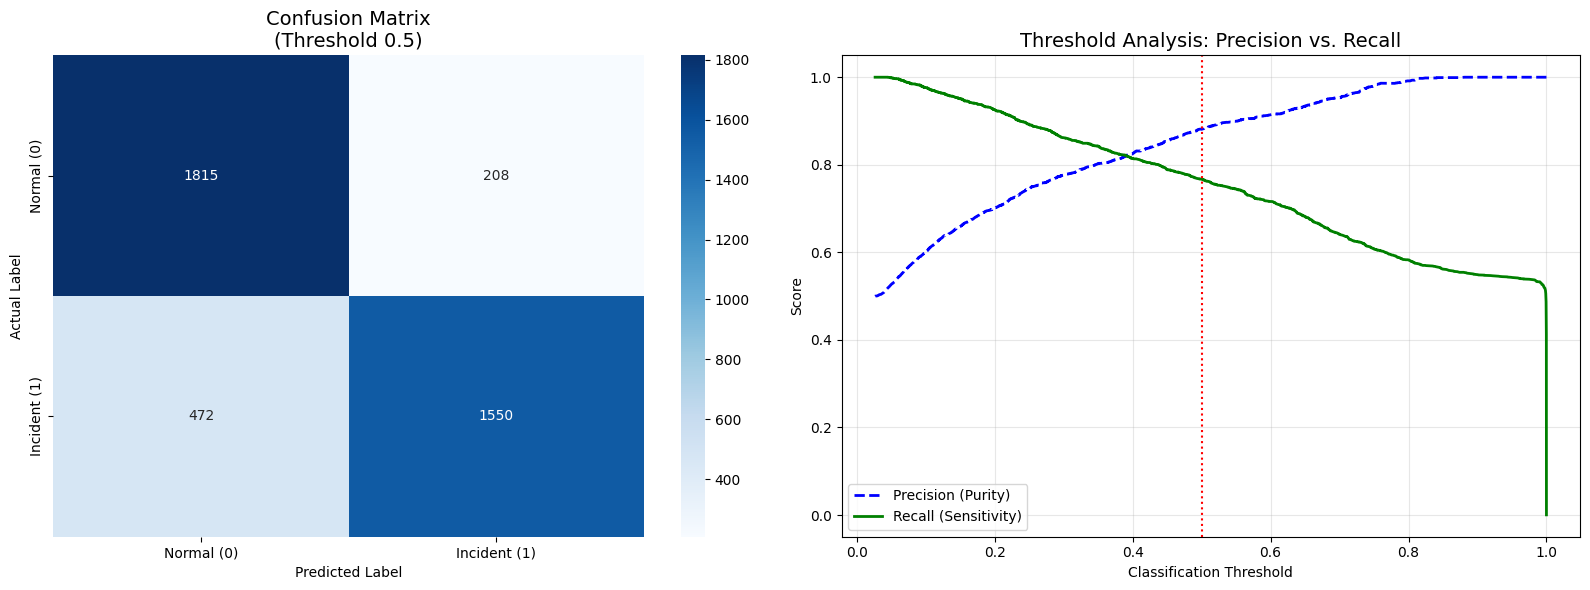

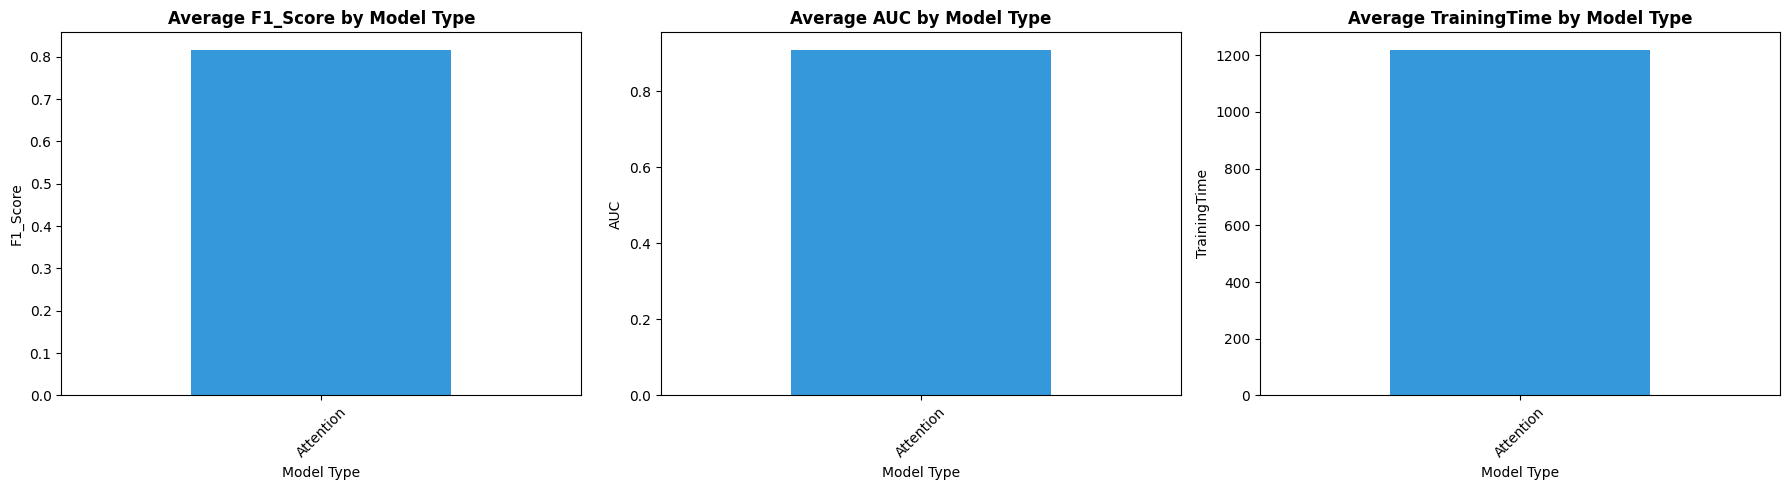


💡 RESOURCE OPTIMIZATION TIP:
   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: 0.346
   Pada titik ini, Precision akan berada di atas 80% dengan Recall sekitar 84.3%.


In [10]:
# === 6. Final Results Visualization & Comparison ===

# 1. Convert the results list to a Pandas DataFrame
res_df = pd.DataFrame(results_all)

# 2. Metadata Extraction
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].fillna(0).astype(int)
res_df['Sampling'] = res_df['Sampling'].fillna('Unknown')

# Identify Method and Type
res_df['Method'] = res_df['Model'].apply(lambda m: 'SMOTE' if 'SMOTE' in m else ('Undersampled' if 'Under' in m else ('ClassWeight' if 'ClassWeight' in m else 'Original')))

# Sort by F1_Score or AUC to find the best model for detailed analysis
res_df = res_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# --- A. Comparative Summary Table ---
print("\n" + "="*90)
print("📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)")
print("="*90)
display(res_df[['Model', 'ModelType', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].round(4))

# --- A.1 Summary by Model Type ---
print("\n" + "="*90)
print("📈 SUMMARY BY MODEL TYPE (Mean Metrics)")
print("="*90)
model_summary = res_df.groupby('ModelType')[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].mean()
display(model_summary.round(4))

# --- B. Detailed Analysis for the BEST MODEL ---
# Ambil data dari model peringkat pertama (Best Model)
best_model_data = res_df.iloc[0]
y_true = best_model_data['y_test']
y_pred = best_model_data['y_pred']
y_prob = best_model_data['y_prob']
model_label = best_model_data['Model']
model_type = best_model_data['ModelType']

print("\n" + "="*90)
print(f"🎯 DETAILED ANALYSIS: {model_label}")
print(f"   Model Type: {model_type}")
print("="*90)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Incident (1)'],
            yticklabels=['Normal (0)', 'Incident (1)'], ax=ax[0])
ax[0].set_title(f"Confusion Matrix\n(Threshold 0.5)", fontsize=14)
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# 2. Threshold Analysis (Precision vs. Recall Trade-off)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

ax[1].plot(thresholds, precisions[:-1], "b--", label="Precision (Purity)", linewidth=2)
ax[1].plot(thresholds, recalls[:-1], "g-", label="Recall (Sensitivity)", linewidth=2)
ax[1].set_xlabel("Classification Threshold")
ax[1].set_ylabel("Score")
ax[1].set_title("Threshold Analysis: Precision vs. Recall", fontsize=14)
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Tambahkan garis bantu untuk melihat dampak terhadap False Positive (Precision)
# Sesuai kebutuhan Anda: meminimalkan False Positive = Mengejar Precision Tinggi
ax[1].axvline(x=0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
plt.tight_layout()
plt.show()

# --- C. Model Type Performance Comparison Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['F1_Score', 'AUC', 'TrainingTime']

for idx, metric in enumerate(metrics_to_plot):
    model_summary[metric].plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    axes[idx].set_title(f'Average {metric} by Model Type', fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel('Model Type')
    axes[idx].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

# --- D. Threshold Optimization for Resource Efficiency ---
# Mencari threshold terbaik jika ingin Precision > 0.8 (Hemat Resource)
target_precision = 0.80
idx = np.where(precisions >= target_precision)[0]

if len(idx) > 0:
    opt_threshold = thresholds[idx[0]]
    opt_recall = recalls[idx[0]]
    print(f"\n💡 RESOURCE OPTIMIZATION TIP:")
    print(f"   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: {opt_threshold:.3f}")
    print(f"   Pada titik ini, Precision akan berada di atas {target_precision*100:.0f}% dengan Recall sekitar {opt_recall*100:.1f}%.")
else:
    print("\n[Notice]: Tidak ditemukan threshold yang mencapai target Precision tersebut.")

In [11]:
for idx, row in res_df.iterrows():
    y_test = row['y_test']
    y_prob = row['y_prob']
    
    print(f"\n{'='*60}")
    print(f"🧠 Model: {row['Model']}")
    print('='*60)
    
    for threshold in [0.44395323276519775]:
        y_pred = (y_prob >= threshold).astype(int)
        print(f"  T={threshold}: Acc={accuracy_score(y_test, y_pred):.3f}, F1={f1_score(y_test, y_pred):.3f}")


🧠 Model: 30min|win=48|f=15-SMOTE-Attention
  T=0.44395323276519777: Acc=0.827, F1=0.822

🧠 Model: 30min|win=60|f=15-SMOTE-Attention
  T=0.44395323276519777: Acc=0.821, F1=0.818
